In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [3]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05

In [57]:
# 次のroundに行く場合はNaNとする
nEstim = 1000
minRatio = 2
#nGrovers = np.arange(70, 700, 10)
nGrovers = [200]
#angleFracs = np.linspace(0, 0.25, num=22)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
angleFracs = np.linspace(0, 0.5, num=22)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf = pd.DataFrame(columns=["nGrover","AngleFrac","ThetaBias","NumSamp","NumEnd"])

for nGrover in nGrovers:
    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = angleFrac * np.pi / (2 * nGrover + 1) # R=0とした場合の対応するθ
        p = np.sin(thetaTemp) ** 2
        errThetas = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2, endCriterion="Angle")
            if result is None:
                errThetas.append(np.nan)
            else:
                pEst = result["Estimate"]
                thetaEst = np.arcsin(np.sqrt(pEst))
                errThetas.append(thetaEst - thetaTemp)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errThetas)
        numSamp = len(errThetas)
        numEnd = numSamp - np.sum(np.isnan(errThetas))
        resDf = resDf.append(pd.Series([nGrover,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

#resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/ThetaBias_VariousNGrovAngleFrac.csv")

200 0.023809523809523808 2023-09-12 11:26:05.272994
200 0.047619047619047616 2023-09-12 11:26:05.522813
200 0.07142857142857142 2023-09-12 11:26:05.719598
200 0.09523809523809523 2023-09-12 11:26:06.020696
200 0.11904761904761904 2023-09-12 11:26:06.330292
200 0.14285714285714285 2023-09-12 11:26:06.651530
200 0.16666666666666666 2023-09-12 11:26:07.051575
200 0.19047619047619047 2023-09-12 11:26:07.498263
200 0.21428571428571427 2023-09-12 11:26:07.950678
200 0.23809523809523808 2023-09-12 11:26:08.382303
200 0.26190476190476186 2023-09-12 11:26:08.793508
200 0.2857142857142857 2023-09-12 11:26:09.229875
200 0.30952380952380953 2023-09-12 11:26:09.676930
200 0.3333333333333333 2023-09-12 11:26:10.148689
200 0.3571428571428571 2023-09-12 11:26:10.590060
200 0.38095238095238093 2023-09-12 11:26:10.994398
200 0.40476190476190477 2023-09-12 11:26:11.319430
200 0.42857142857142855 2023-09-12 11:26:11.582142
200 0.45238095238095233 2023-09-12 11:26:11.817119
200 0.47619047619047616 2023-09-

In [58]:
resDf

,nGrover,AngleFrac,ThetaBias,NumSamp,NumEnd
0,200.0,0.023810,-1.512911e-04,1000.0,1000.0
1,200.0,0.047619,-2.550878e-04,1000.0,1000.0
2,200.0,0.071429,-2.665083e-04,1000.0,1000.0
3,200.0,0.095238,-2.779794e-04,1000.0,1000.0
4,200.0,0.119048,-2.348624e-04,1000.0,1000.0
5,200.0,0.142857,-1.865826e-04,1000.0,1000.0
6,200.0,0.166667,-1.143315e-04,1000.0,1000.0
7,200.0,0.190476,-5.442048e-05,1000.0,1000.0
8,200.0,0.214286,-9.612290e-07,1000.0,1000.0
9,200.0,0.238095,-1.218817e-05,1000.0,1000.0


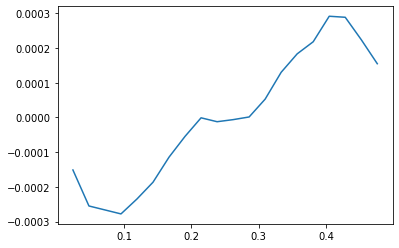

In [59]:
ax = plt.gca()
plt.plot(resDf["AngleFrac"], resDf["ThetaBias"])
plt.show()

In [51]:
nEstim = 1000
minRatio = 2
nGrover = 100
angleFracs = np.linspace(0, 0.5, num=22)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","ThetaBias","NumSamp","NumEnd"])

rs = np.arange(0, nGrover, 10)

for r in rs:
    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac * np.pi) / (2 * nGrover + 1) # R=0とした場合の対応するθ
        p = np.sin(thetaTemp) ** 2
        errThetas = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2, endCriterion="Angle")
            if result is None:
                errThetas.append(np.nan)
            else:
                pEst = result["Estimate"]
                thetaEst = np.arcsin(np.sqrt(pEst))
                errThetas.append(thetaEst - thetaTemp)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errThetas)
        numSamp = len(errThetas)
        numEnd = numSamp - np.sum(np.isnan(errThetas))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

100 0.023809523809523808 2023-09-12 11:18:27.318723
100 0.047619047619047616 2023-09-12 11:18:27.580900


<ipython-input-51-2cc6ec1409b6>:25: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errThetas)


100 0.07142857142857142 2023-09-12 11:18:27.848228
100 0.09523809523809523 2023-09-12 11:18:28.165548
100 0.11904761904761904 2023-09-12 11:18:28.501916
100 0.14285714285714285 2023-09-12 11:18:29.005532
100 0.16666666666666666 2023-09-12 11:18:29.983497
100 0.19047619047619047 2023-09-12 11:18:33.151721
100 0.21428571428571427 2023-09-12 11:18:40.297987
100 0.23809523809523808 2023-09-12 11:18:48.581409
100 0.26190476190476186 2023-09-12 11:18:54.630267
100 0.2857142857142857 2023-09-12 11:18:58.006505
100 0.30952380952380953 2023-09-12 11:19:00.014476
100 0.3333333333333333 2023-09-12 11:19:01.854738
100 0.3571428571428571 2023-09-12 11:19:04.429375
100 0.38095238095238093 2023-09-12 11:19:12.208881
100 0.40476190476190477 2023-09-12 11:19:30.797550
100 0.42857142857142855 2023-09-12 11:19:48.901073
100 0.45238095238095233 2023-09-12 11:20:02.371375
100 0.47619047619047616 2023-09-12 11:20:10.871556
100 0.023809523809523808 2023-09-12 11:20:17.889396
100 0.047619047619047616 2023-09-

In [52]:
resDf

,nGrover,r,AngleFrac,ThetaBias,NumSamp,NumEnd
0,100.0,0.0,0.023810,NaN,1000.0,0.0
1,100.0,0.0,0.047619,NaN,1000.0,0.0
2,100.0,0.0,0.071429,NaN,1000.0,0.0
3,100.0,0.0,0.095238,NaN,1000.0,0.0
4,100.0,0.0,0.119048,NaN,1000.0,0.0
...,...,...,...,...,...,...
195,100.0,90.0,0.380952,NaN,1000.0,0.0
196,100.0,90.0,0.404762,NaN,1000.0,0.0
197,100.0,90.0,0.428571,NaN,1000.0,0.0
198,100.0,90.0,0.452381,NaN,1000.0,0.0


In [53]:
resDf[resDf["r"] == 0]

,nGrover,r,AngleFrac,ThetaBias,NumSamp,NumEnd
0,100.0,0.0,0.023810,NaN,1000.0,0.0
1,100.0,0.0,0.047619,NaN,1000.0,0.0
2,100.0,0.0,0.071429,NaN,1000.0,0.0
3,100.0,0.0,0.095238,NaN,1000.0,0.0
4,100.0,0.0,0.119048,NaN,1000.0,0.0
5,100.0,0.0,0.142857,NaN,1000.0,0.0
6,100.0,0.0,0.166667,0.000440,1000.0,26.0
7,100.0,0.0,0.190476,0.000087,1000.0,64.0
8,100.0,0.0,0.214286,-0.000264,1000.0,40.0
9,100.0,0.0,0.238095,-0.000629,1000.0,8.0


In [54]:
resDf[resDf["r"] == 10]

,nGrover,r,AngleFrac,ThetaBias,NumSamp,NumEnd
20,100.0,10.0,0.023810,NaN,1000.0,0.0
21,100.0,10.0,0.047619,NaN,1000.0,0.0
22,100.0,10.0,0.071429,NaN,1000.0,0.0
23,100.0,10.0,0.095238,NaN,1000.0,0.0
24,100.0,10.0,0.119048,NaN,1000.0,0.0
25,100.0,10.0,0.142857,NaN,1000.0,0.0
26,100.0,10.0,0.166667,NaN,1000.0,0.0
27,100.0,10.0,0.190476,NaN,1000.0,0.0
28,100.0,10.0,0.214286,NaN,1000.0,0.0
29,100.0,10.0,0.238095,NaN,1000.0,0.0


In [55]:
resDf[resDf["r"] == 20]

,nGrover,r,AngleFrac,ThetaBias,NumSamp,NumEnd
40,100.0,20.0,0.023810,NaN,1000.0,0.0
41,100.0,20.0,0.047619,NaN,1000.0,0.0
42,100.0,20.0,0.071429,NaN,1000.0,0.0
43,100.0,20.0,0.095238,NaN,1000.0,0.0
44,100.0,20.0,0.119048,NaN,1000.0,0.0
45,100.0,20.0,0.142857,NaN,1000.0,0.0
46,100.0,20.0,0.166667,NaN,1000.0,0.0
47,100.0,20.0,0.190476,NaN,1000.0,0.0
48,100.0,20.0,0.214286,NaN,1000.0,0.0
49,100.0,20.0,0.238095,NaN,1000.0,0.0


In [56]:
resDf[resDf["r"] == 50]

,nGrover,r,AngleFrac,ThetaBias,NumSamp,NumEnd
100,100.0,50.0,0.023810,NaN,1000.0,0.0
101,100.0,50.0,0.047619,NaN,1000.0,0.0
102,100.0,50.0,0.071429,NaN,1000.0,0.0
103,100.0,50.0,0.095238,NaN,1000.0,0.0
104,100.0,50.0,0.119048,NaN,1000.0,0.0
105,100.0,50.0,0.142857,NaN,1000.0,0.0
106,100.0,50.0,0.166667,NaN,1000.0,0.0
107,100.0,50.0,0.190476,NaN,1000.0,0.0
108,100.0,50.0,0.214286,NaN,1000.0,0.0
109,100.0,50.0,0.238095,NaN,1000.0,0.0


In [60]:
nEstim = 1000
minRatio = 2
nGrover = 200
angleFracs = np.linspace(0, 0.5, num=22)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","ThetaBias","NumSamp","NumEnd"])

rs = np.arange(0, nGrover, 10)

for r in rs:
    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac * np.pi) / (2 * nGrover + 1) # R=0とした場合の対応するθ
        p = np.sin(thetaTemp) ** 2
        errThetas = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2, endCriterion="Angle")
            if result is None:
                errThetas.append(np.nan)
            else:
                pEst = result["Estimate"]
                thetaEst = np.arcsin(np.sqrt(pEst))
                errThetas.append(thetaEst - thetaTemp)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errThetas)
        numSamp = len(errThetas)
        numEnd = numSamp - np.sum(np.isnan(errThetas))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

200 0.023809523809523808 2023-09-12 11:27:04.337754
200 0.047619047619047616 2023-09-12 11:27:04.591643
200 0.07142857142857142 2023-09-12 11:27:04.818988
200 0.09523809523809523 2023-09-12 11:27:05.069010
200 0.11904761904761904 2023-09-12 11:27:05.317323
200 0.14285714285714285 2023-09-12 11:27:05.642780
200 0.16666666666666666 2023-09-12 11:27:06.090702
200 0.19047619047619047 2023-09-12 11:27:06.536552
200 0.21428571428571427 2023-09-12 11:27:07.022325
200 0.23809523809523808 2023-09-12 11:27:07.450495
200 0.26190476190476186 2023-09-12 11:27:07.860583
200 0.2857142857142857 2023-09-12 11:27:08.282408
200 0.30952380952380953 2023-09-12 11:27:08.718851
200 0.3333333333333333 2023-09-12 11:27:09.216813
200 0.3571428571428571 2023-09-12 11:27:09.660383
200 0.38095238095238093 2023-09-12 11:27:10.037463
200 0.40476190476190477 2023-09-12 11:27:10.358556
200 0.42857142857142855 2023-09-12 11:27:10.619487
200 0.45238095238095233 2023-09-12 11:27:10.841997
200 0.47619047619047616 2023-09-

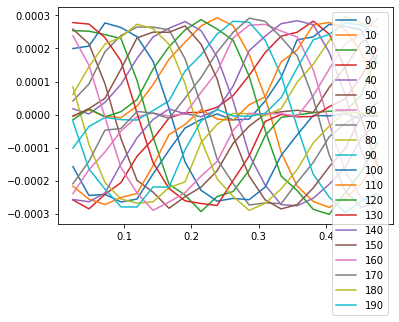

In [61]:
ax = plt.gca()
for r in rs:
    resDfPart = resDf[resDf["r"] == r]
    plt.plot(resDfPart["AngleFrac"], resDfPart["ThetaBias"], label=str(r))
plt.legend()
plt.show()

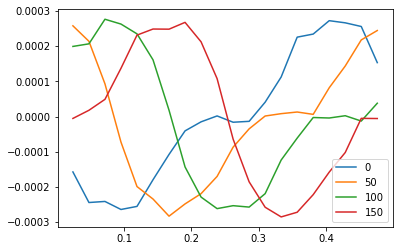

In [62]:
ax = plt.gca()
for r in [0, 50, 100, 150]:
    resDfPart = resDf[resDf["r"] == r]
    plt.plot(resDfPart["AngleFrac"], resDfPart["ThetaBias"], label=str(r))
plt.legend()
plt.show()